In [1]:
import sys
import os

# Ensure the src and ux_ui directories are in the Python path
sys.path.append(os.path.abspath('./src'))
sys.path.append(os.path.abspath('./ux_ui'))

from src.project_manager import ProjectManager  # Correctly import the ProjectManager class
# Initialize the ProjectManager with the base directory
base_directory = '../data/v3.0_las_files'
project_manager_instance = ProjectManager(base_directory)
project_manager_instance.selected_field = 'Scoda'

# Load the project with progress callback (set to None since we're not using UI)
project = project_manager_instance.load_selected_field(progress_callback=None)

project_manager_instance.selected_curves = ['DCAL', 'SCAL', 'MCAL', 'GR', 'SP', 'MN', 'MI', 'RILM', 'RILD', 'RLL3', 'RXORT', 'RHOB', 'RHOC', 'CILD', 'DPOR', 'SPOR', 'DT', 'CNLS']

project_manager_instance.standardized_curve_mapping = {
    'Cali': ['DCAL', 'SCAL', 'MCAL'],
    'GR-SP': ['GR', 'SP'],
    'Micro': ['MN', 'MI'],
    'RIL': ['RILM', 'RILD', 'RLL3', 'RXORT'],
    'Density': ['RHOB', 'RHOC', 'CILD', 'DPOR'], 
    'Sonic': ['SPOR', 'DT'],
    'Neutron': ['CNLS'] # 
    }

# Run funtion to determined outliers
project_manager_instance.detect_all_outliers()

# Filter outliers (make sure to call the method with parentheses)
project_manager_instance.prepare_data()

data = project_manager_instance.prepared_data
selected_curves = ['Cali', 'GR', 'SP', 'MN', 'MI', 'RILM', 'RILD', 'RLL3', 'RXORT', 'RHOB', 'RHOC', 'CILD', 'DPOR', 'SPOR', 'DT']
unique_formations = project_manager_instance.unique_formations
curves_to_predict = ['CNLS', 'Formation']


Data has been prepared successfully.


In [2]:
from src.neural_network.pipeline import pipeline
from src.neural_network.hyperparameters import *

train_validation_data, external_test_data, engineered_data, feature_info  = pipeline(
         data, selected_curves, curves_to_predict)
     

2025-04-11 17:20:52.556052: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-11 17:20:52.591700: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4080, compute capability 8.9


2025-04-11 17:20:53.619458: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:999] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 17:20:53.635314: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:999] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 17:20:53.635380: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:999] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 17:20:53.635893: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:999] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 17:20:53,637 - src.utils.initialize_g

# Step 2 ----- Feature Engineering -----


=== Categorical Variables Analysis in Engineered Data ===
Found 7 categorical variables across 19 wells

--- Variable: Formation ---
Present in 19/19 wells (100.00%)
              Value  Count Percentage
            Foraker   4661     18.33%
            Unknown   4056     15.95%
Lansing-Kansas City   3754     14.76%
               Neva   2734     10.75%
          Anhydrite   2592     10.19%
             Topeka   2557     10.06%
        Stark Shale   2014      7.92%
              Oread   1043      4.10%
              Stark    962      3.78%
          Red Eagle    554      2.18%
              LKC D    222      0.87%
            Stotler    216      0.85%
              LKC H     61      0.24%


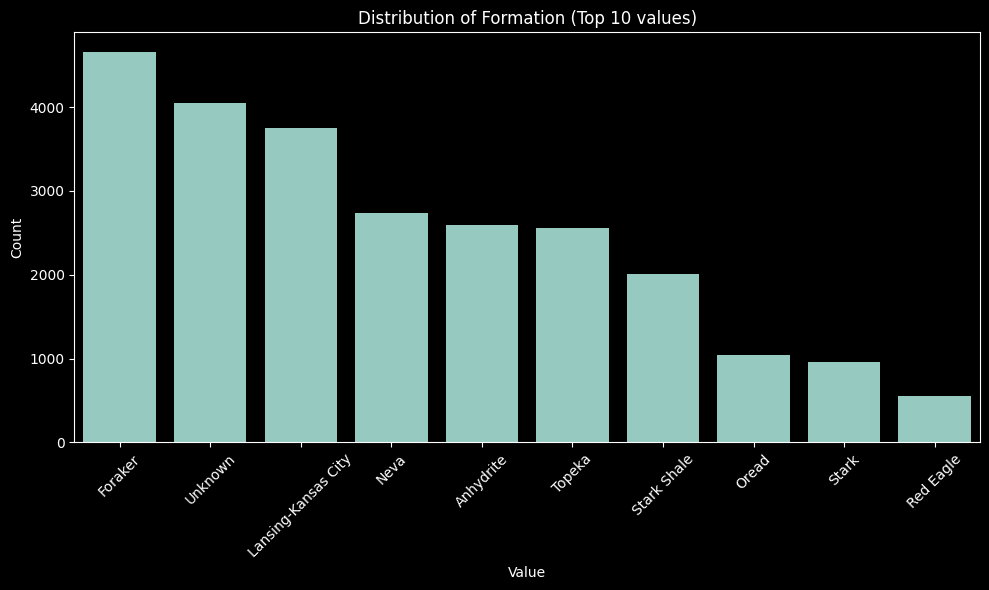


--- Variable: Phi_class ---
Present in 19/19 wells (100.00%)
 Value  Count Percentage
     1   3665     14.41%
     0   3159     12.42%
     4   2934     11.54%
     8   2852     11.22%
     6   2767     10.88%
     7   2372      9.33%
     3   2313      9.10%
     2   2037      8.01%
     9   1971      7.75%
     5   1356      5.33%


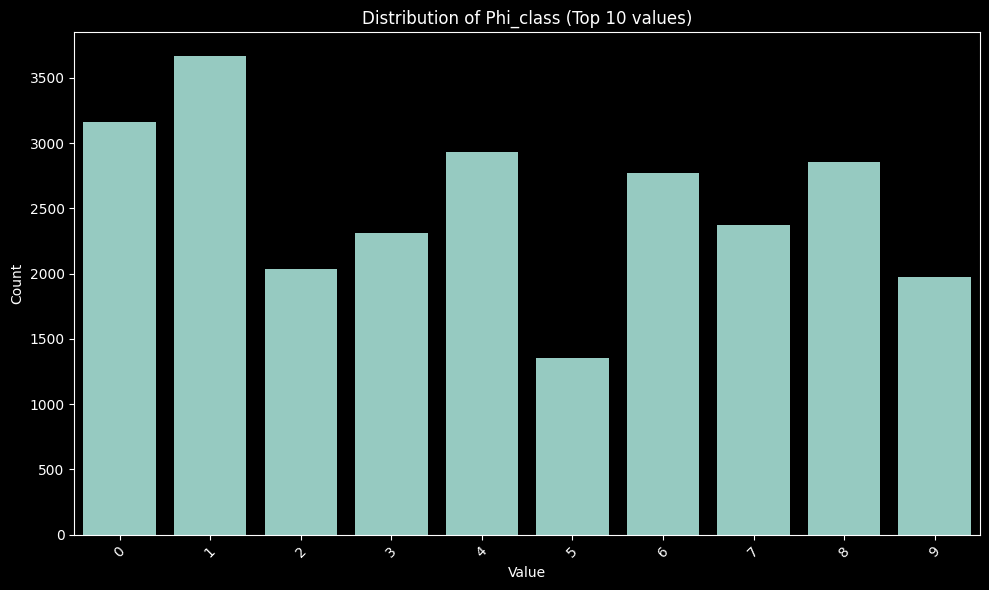


--- Variable: SwVsh_class ---
Present in 19/19 wells (100.00%)
 Value  Count Percentage
     1   3278     12.89%
     0   2970     11.68%
     3   2664     10.48%
    10   2660     10.46%
     7   2543     10.00%
     2   2413      9.49%
     4   2022      7.95%
    11   1828      7.19%
     9   1650      6.49%
     5   1629      6.41%
     8    896      3.52%
     6    873      3.43%


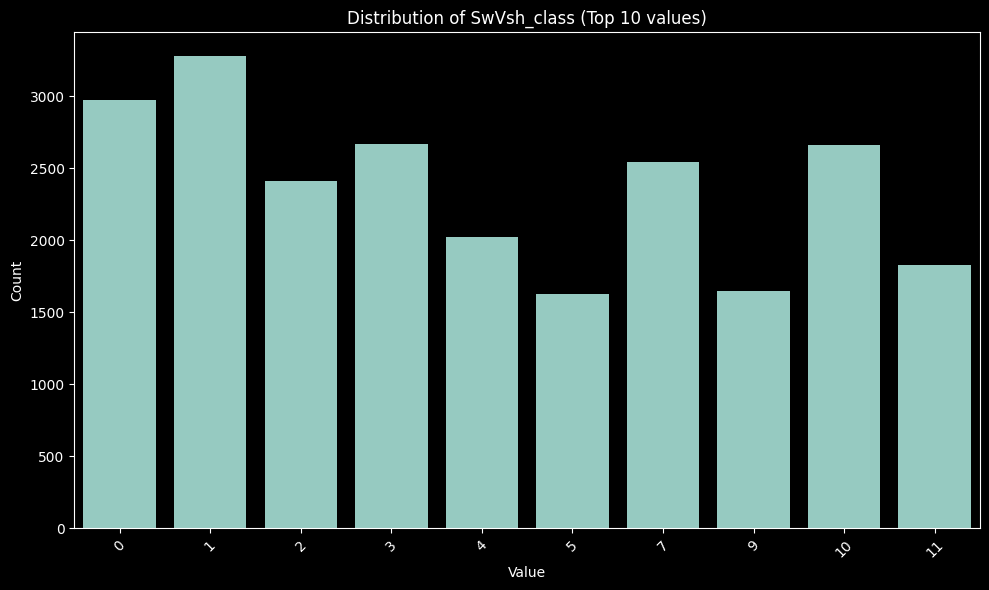


--- Variable: Vsh_class ---
Present in 19/19 wells (100.00%)
 Value  Count Percentage
     2  11653     45.83%
     3   7106     27.95%
     1   4457     17.53%
     4    978      3.85%
     0    927      3.65%
     5    305      1.20%


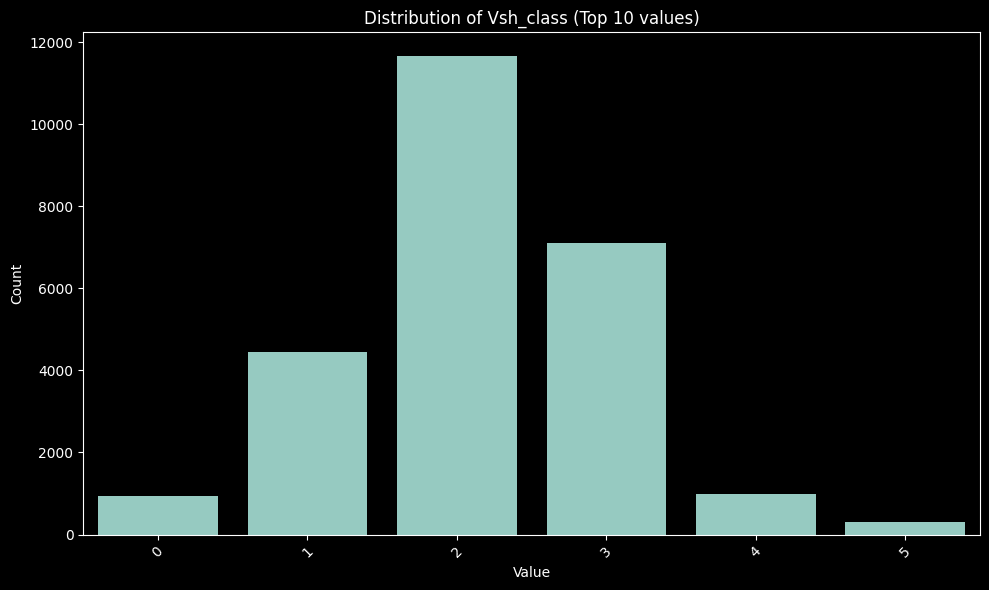


--- Variable: Well_ID ---
Error processing column 'Well_ID' in well 'Walter 1-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Ladenburger 1-6': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Walter 4-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Walter 6-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Mary Ann 3-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Walter 5-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Mary Ann 6-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Ladenburger 'B' 1-6': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Mary Ann 1-1': Grouper for 'Well_ID' not 1-dimensional
Error processing column 'Well_ID' in well 'Walter 7-1': Grouper for 'Well_ID' not 1-dimen

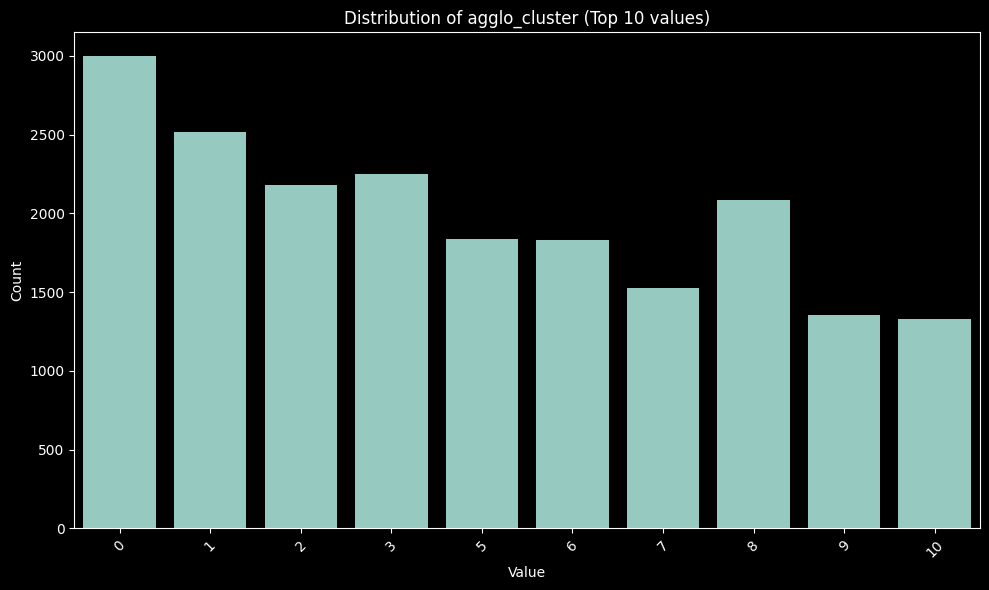


--- Variable: kmeans_cluster ---
Present in 19/19 wells (100.00%)
 Value  Count Percentage
     1   2201      8.66%
     2   2179      8.57%
     3   2013      7.92%
     4   1900      7.47%
     0   1893      7.45%
    11   1794      7.06%
     7   1750      6.88%
    14   1743      6.86%
     5   1734      6.82%
     6   1614      6.35%
     8   1509      5.93%
    10   1425      5.60%
    13   1395      5.49%
     9   1231      4.84%
    12   1045      4.11%


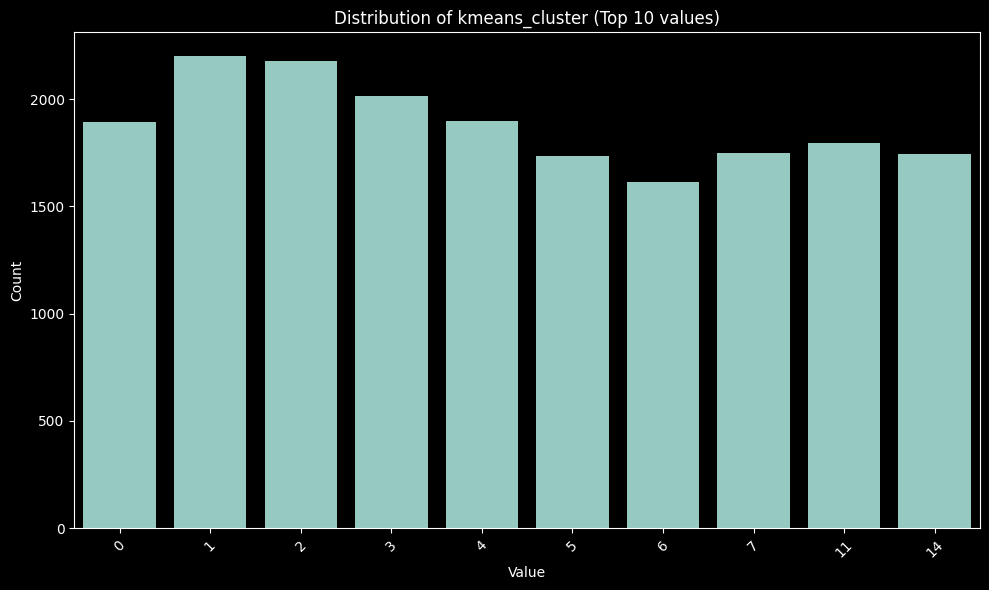

In [4]:
# Print a table with categorical variables data from engineered_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Categorical Variables Analysis in Engineered Data ===")

# Function to analyze categorical columns in a dataframe
def analyze_categorical_data(df):
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
    return categorical_cols

# Initialize counters for statistics
total_wells = len(engineered_data)
categorical_stats = {}

# Collect all categorical columns across all wells
all_categorical_cols = set()
for well_name, df in engineered_data.items():
    cat_cols = analyze_categorical_data(df)
    all_categorical_cols.update(cat_cols)

print(f"Found {len(all_categorical_cols)} categorical variables across {total_wells} wells")

# Create a summary table for each categorical variable
for col in sorted(all_categorical_cols):
    print(f"\n--- Variable: {col} ---")
    
    # Collect value counts across all wells
    all_values = {}
    wells_with_col = 0
    
    for well_name, df in engineered_data.items():
        if col in df.columns and col in analyze_categorical_data(df):
            wells_with_col += 1
            # Handle multi-dimensional columns that cause ValueError
            try:
                value_counts = df[col].value_counts().to_dict()
                
                for val, count in value_counts.items():
                    if val in all_values:
                        all_values[val] += count
                    else:
                        all_values[val] = count
            except ValueError as e:
                print(f"Error processing column '{col}' in well '{well_name}': {e}")
                continue
    
    # Create and display the summary table
    if all_values:
        summary_df = pd.DataFrame({
            'Value': list(all_values.keys()),
            'Count': list(all_values.values())
        })
        summary_df['Percentage'] = summary_df['Count'] / summary_df['Count'].sum() * 100
        summary_df = summary_df.sort_values('Count', ascending=False).reset_index(drop=True)
        summary_df['Percentage'] = summary_df['Percentage'].map('{:.2f}%'.format)
        
        print(f"Present in {wells_with_col}/{total_wells} wells ({wells_with_col/total_wells:.2%})")
        print(summary_df.to_string(index=False))
        
        # Plot distribution for this categorical variable
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Value', y='Count', data=summary_df.head(10))
        plt.title(f'Distribution of {col} (Top 10 values)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [5]:
# Analyze which columns are categorical across all wells

# Initialize dictionaries to track column types
categorical_columns = {}
numerical_columns = {}
coordinate_columns = {}

# Analyze each well's data
for well_name, df in engineered_data.items():
    for col in df.columns:
        # Check if column is categorical
        is_categorical = (
            pd.api.types.is_categorical_dtype(df[col]) or 
            (col in feature_info and feature_info[col] == 'categorical')
        )
        
        # Check if column is a coordinate
        is_coordinate = (
            col in ['Latitude', 'Longitude'] or
            (col in feature_info and feature_info[col] == 'coordinate')
        )
        
        # Update counters
        if is_categorical:
            categorical_columns[col] = categorical_columns.get(col, 0) + 1
        elif is_coordinate:
            coordinate_columns[col] = coordinate_columns.get(col, 0) + 1
        else:
            numerical_columns[col] = numerical_columns.get(col, 0) + 1

# Print summary of column types
print("=== Column Type Analysis ===")
print(f"\nCategorical Columns ({len(categorical_columns)}):")
for col, count in sorted(categorical_columns.items(), key=lambda x: x[1], reverse=True):
    print(f"  - {col}: present in {count}/{total_wells} wells ({count/total_wells:.2%})")

print(f"\nCoordinate Columns ({len(coordinate_columns)}):")
for col, count in sorted(coordinate_columns.items(), key=lambda x: x[1], reverse=True):
    print(f"  - {col}: present in {count}/{total_wells} wells ({count/total_wells:.2%})")

print(f"\nNumerical Columns: {len(numerical_columns)} columns")
print(f"Total Columns: {len(categorical_columns) + len(coordinate_columns) + len(numerical_columns)}")

# Create a pie chart showing the distribution of column types
plt.figure(figsize=(10, 6))
plt.pie(
    [len(categorical_columns), len(coordinate_columns), len(numerical_columns)],
    labels=['Categorical', 'Coordinate', 'Numerical'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99']
)
plt.title('Distribution of Column Types')
plt.axis('equal')
plt.show()


NameError: name 'feature_info' is not defined

In [ ]:
# Check for NaN values in train_validation_data
print("=== NaN Values Analysis in Train/Validation Data ===")

# Initialize counters for statistics
total_sets = len(train_validation_data)
sets_with_nans = 0
total_cells = 0
total_nan_cells = 0

# Analyze each dataset in the dictionary
for set_name, df in train_validation_data.items():
    # Count NaNs in this dataset
    nan_count = df.isna().sum()
    set_total_cells = df.size
    set_nan_cells = df.isna().sum().sum()
    
    total_cells += set_total_cells
    total_nan_cells += set_nan_cells
    
    # Check if this dataset has any NaNs
    if set_nan_cells > 0:
        sets_with_nans += 1
        print(f"\nDataset: {set_name}")
        print(f"  Total NaN cells: {set_nan_cells} ({set_nan_cells/set_total_cells:.2%} of data)")
        
        # Show columns with NaNs
        cols_with_nans = nan_count[nan_count > 0]
        if not cols_with_nans.empty:
            print("  Columns with NaNs:")
            for col, count in cols_with_nans.items():
                print(f"    - {col}: {count} NaNs ({count/len(df):.2%} of column)")
                
            # Visualize NaN distribution for this dataset
            plt.figure(figsize=(12, 6))
            plt.title(f'NaN Distribution in {set_name}')
            plt.imshow(df.isna(), cmap='viridis', aspect='auto')
            plt.xlabel('Features')
            plt.ylabel('Samples')
            plt.show()

# Print summary statistics
print("\n=== NaN Summary Statistics ===")
print(f"Datasets with NaNs: {sets_with_nans}/{total_sets} ({sets_with_nans/total_sets:.2%})")
print(f"Total NaN cells: {total_nan_cells}/{total_cells} ({total_nan_cells/total_cells:.2%} of all data)")

In [ ]:
# Check for NaN values in engineered data
print("=== NaN Values Analysis in Engineered Data ===")
import matplotlib.pyplot as plt  # Correct import for matplotlib

# Initialize counters for statistics
total_wells = len(engineered_data)
wells_with_nans = 0
total_cells = 0
total_nan_cells = 0
nan_columns = {}

# Analyze each well
for well_name, well_df in engineered_data.items():
    # Count NaNs in this well
    nan_count = well_df.isna().sum()
    well_total_cells = well_df.size
    well_nan_cells = well_df.isna().sum().sum()
    
    total_cells += well_total_cells
    total_nan_cells += well_nan_cells
    
    # Track columns with NaNs
    for col, count in nan_count.items():
        if count > 0:
            if col not in nan_columns:
                nan_columns[col] = {'wells': 0, 'total_nans': 0}
            nan_columns[col]['wells'] += 1
            nan_columns[col]['total_nans'] += count
    
    # Check if this well has any NaNs
    if well_nan_cells > 0:
        wells_with_nans += 1
        print(f"\nWell: {well_name}")
        print(f"  Total NaN cells: {well_nan_cells} ({well_nan_cells/well_total_cells:.2%} of data)")
        
        # Show columns with NaNs
        cols_with_nans = nan_count[nan_count > 0]
        if not cols_with_nans.empty:
            print("  Columns with NaNs:")
            for col, count in cols_with_nans.items():
                print(f"    - {col}: {count} NaNs ({count/len(well_df):.2%} of column)")

# Print summary statistics
print("\n=== NaN Summary Statistics ===")
print(f"Wells with NaNs: {wells_with_nans}/{total_wells} ({wells_with_nans/total_wells:.2%})")
print(f"Total NaN cells: {total_nan_cells}/{total_cells} ({total_nan_cells/total_cells:.2%} of all data)")

# Print columns most affected by NaNs
if nan_columns:
    print("\n=== Columns Most Affected by NaNs ===")
    sorted_cols = sorted(nan_columns.items(), key=lambda x: x[1]['total_nans'], reverse=True)
    for col, stats in sorted_cols[:10]:  # Show top 10 columns
        print(f"{col}: {stats['total_nans']} NaNs across {stats['wells']} wells")

# Visualize NaN distribution in a sample well (first well with NaNs)
if wells_with_nans > 0:
    sample_well_name = next((name for name, df in engineered_data.items() 
                            if df.isna().sum().sum() > 0), None)
    if sample_well_name:
        sample_df = engineered_data[sample_well_name]
        
        plt.figure(figsize=(12, 6))
        plt.title(f"NaN Distribution in Sample Well: {sample_well_name}")
        
        # Create heatmap-like visualization of NaNs
        nan_mask = sample_df.isna()
        plt.imshow(nan_mask, aspect='auto', cmap='viridis')
        plt.colorbar(label='Is NaN')
        plt.xlabel('Features')
        plt.ylabel('Samples')
        
        # Add x-ticks for column names (limit to avoid overcrowding)
        if len(sample_df.columns) <= 20:
            plt.xticks(range(len(sample_df.columns)), sample_df.columns, rotation=90)
        else:
            # Show only a subset of column names
            step = len(sample_df.columns) // 20
            plt.xticks(range(0, len(sample_df.columns), step), 
                      [sample_df.columns[i] for i in range(0, len(sample_df.columns), step)], 
                      rotation=90)
        
        plt.tight_layout()
        plt.show()



In [ ]:
# Print Formation values in engineered features
print("=== Formation values in engineered data ===")

# Check if Formation exists in the engineered data
sample_well = next(iter(engineered_data.values()))
if 'Formation' in sample_well.columns:
    # Get all unique Formation values across all wells
    all_formations = set()
    formation_counts = {}
    
    for well_name, well_data in engineered_data.items():
        if 'Formation' in well_data.columns:
            well_formations = well_data['Formation'].unique()
            all_formations.update(well_formations)
            
            # Count occurrences per well
            formation_counts[well_name] = well_data['Formation'].value_counts().to_dict()
            
            # Print summary for this well
            print(f"\nWell: {well_name}")
            print(f"  Formation values: {sorted(well_formations)}")
            print(f"  Formation counts: {well_data['Formation'].value_counts().to_dict()}")
    
    # Print overall summary
    print("\nOverall Formation Summary:")
    print(f"  Total unique Formation values: {len(all_formations)}")
    print(f"  All Formation values: {sorted(all_formations)}")
    
    # Check data type of Formation column
    print(f"\nFormation data type: {sample_well['Formation'].dtype}")
    
    # Check if Formation is treated as categorical in feature_info
    if 'feature_info' in locals() or 'feature_info' in globals():
        if 'Formation' in feature_info:
            print(f"Formation type in feature_info: {feature_info['Formation']}")
else:
    print("Formation column not found in engineered data")


In [ ]:
# Analyze variance of engineered features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all wells data for variance analysis
combined_data = pd.concat([df for df in engineered_data.values()], ignore_index=True)

# Get numerical columns only
numerical_cols = [col for col in combined_data.columns 
                 if pd.api.types.is_numeric_dtype(combined_data[col]) 
                 and col not in curves_to_predict]

# Calculate variance for each numerical column
variance_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Variance': [combined_data[col].var() for col in numerical_cols]
})

# Sort by variance in descending order
variance_df = variance_df.sort_values('Variance', ascending=False).reset_index(drop=True)

# Display the top 20 features with highest variance
print("Top 20 features with highest variance:")
display(variance_df.head(20))

# Display the bottom 20 features with lowest variance
print("\nBottom 20 features with lowest variance:")
display(variance_df.tail(20))

# Plot variance distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(variance_df['Variance'], kde=True)
plt.title('Distribution of Feature Variances')
plt.xlabel('Variance')
plt.ylabel('Count')

# Plot top 15 features by variance
plt.subplot(1, 2, 2)
top_15 = variance_df.head(15)
sns.barplot(x='Variance', y='Feature', data=top_15)
plt.title('Top 15 Features by Variance')
plt.tight_layout()
plt.show()

# Calculate well-wise variance
well_variance = {}
for well_name, well_data in engineered_data.items():
    # Get numerical columns for this well
    well_num_cols = [col for col in well_data.columns 
                    if pd.api.types.is_numeric_dtype(well_data[col]) 
                    and col not in curves_to_predict]
    
    # Calculate variance for each column
    well_variance[well_name] = {col: well_data[col].var() for col in well_num_cols}

# Convert to DataFrame for easier analysis
well_variance_df = pd.DataFrame(well_variance)

# Calculate mean variance across wells for each feature
mean_variance = well_variance_df.mean(axis=1).sort_values(ascending=False)

# Plot top 15 features by mean variance across wells
plt.figure(figsize=(10, 6))
mean_variance.head(15).plot(kind='bar')
plt.title('Top 15 Features by Mean Variance Across Wells')
plt.ylabel('Mean Variance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate coefficient of variation (CV) for each feature
# CV = std / mean (normalized measure of dispersion)
cv_df = pd.DataFrame({
    'Feature': numerical_cols,
    'CV': [combined_data[col].std() / (abs(combined_data[col].mean()) + 1e-10) for col in numerical_cols]
})

# Sort by CV in descending order
cv_df = cv_df.sort_values('CV', ascending=False).reset_index(drop=True)

# Display the top 20 features with highest CV
print("\nTop 20 features with highest coefficient of variation (CV):")
display(cv_df.head(20))

# Plot top 15 features by CV
plt.figure(figsize=(10, 6))
sns.barplot(x='CV', y='Feature', data=cv_df.head(15))
plt.title('Top 15 Features by Coefficient of Variation')
plt.tight_layout()
plt.show()


In [ ]:
# Visualize the distribution of engineered features by well
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Function to plot histograms and boxplots for feature distributions
def plot_feature_distributions(data_dict, columns, n_cols=3, figsize=(18, 15)):
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(n_rows, n_cols, figure=fig)
    
    # Combine all wells data for overall distribution
    combined_data = pd.concat([df for df in data_dict.values()], ignore_index=True)
    
    for i, col in enumerate(columns):
        row, col_idx = divmod(i, n_cols)
        ax = fig.add_subplot(gs[row, col_idx])
        
        if col in combined_data.columns:
            # Filter out extreme outliers for better visualization
            data_to_plot = combined_data[col].dropna()
            q1, q3 = np.percentile(data_to_plot, [25, 75])
            iqr = q3 - q1
            lower_bound = q1 - 3 * iqr
            upper_bound = q3 + 3 * iqr
            filtered_data = data_to_plot[(data_to_plot >= lower_bound) & (data_to_plot <= upper_bound)]
            
            # Plot histogram with KDE
            sns.histplot(filtered_data, kde=True, ax=ax, color='skyblue')
            
            # Add boxplot at the bottom of the histogram
            divider = ax.get_position()
            box_height = divider.height * 0.2
            box_ax = fig.add_axes([divider.x0, divider.y0 - box_height, divider.width, box_height])
            sns.boxplot(x=filtered_data, ax=box_ax, color='lightgreen')
            box_ax.set_xlabel('')
            box_ax.set_yticks([])
            
            # Add statistics
            stats_text = f"Mean: {filtered_data.mean():.2f}\nStd: {filtered_data.std():.2f}\n"
            stats_text += f"Min: {filtered_data.min():.2f}\nMax: {filtered_data.max():.2f}"
            ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.set_title(col)
        
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    return fig

# Get numerical columns from the first well
first_well_df = next(iter(engineered_data.values()))
numerical_cols = first_well_df.select_dtypes(include=[np.number]).columns.tolist()

# Plot distributions for the first 15 numerical columns
first_cols = numerical_cols[:15]
fig1 = plot_feature_distributions(engineered_data, first_cols)
plt.suptitle("Distribución de características (1/3)", y=1.02, fontsize=16)
plt.show()

# Plot distributions for the next 15 numerical columns
if len(numerical_cols) > 15:
    second_cols = numerical_cols[15:30]
    fig2 = plot_feature_distributions(engineered_data, second_cols)
    plt.suptitle("Distribución de características (2/3)", y=1.02, fontsize=16)
    plt.show()

# Plot distributions for the remaining numerical columns
if len(numerical_cols) > 30:
    remaining_cols = numerical_cols[30:45]
    fig3 = plot_feature_distributions(engineered_data, remaining_cols)
    plt.suptitle("Distribución de características (3/3)", y=1.02, fontsize=16)
    plt.show()

# Print summary statistics for all wells
print("Resumen estadístico de los pozos:")
for well_name, df in engineered_data.items():
    print(f"\nPozo: {well_name} - {len(df)} muestras")
    print(df.describe().T[['count', 'mean', 'std', 'min', 'max']].head(5))



In [ ]:
# Calculate variance for each column in engineered_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Combine all wells from engineered_data into a single DataFrame
combined_engineered_df = pd.concat([df for df in engineered_data.values()], ignore_index=True)

# Calculate variance for each numerical column
engineered_column_variances = combined_engineered_df.var(numeric_only=True).sort_values(ascending=False)

# Display the variances
print("Global variance for each numerical column in engineered_data:")
print(engineered_column_variances)

# # Visualize the top 20 columns with highest variance
# plt.figure(figsize=(12, 8))
# engineered_column_variances.head(20).plot(kind='bar')
# plt.title('Top 20 Engineered Features with Highest Variance')
# plt.ylabel('Variance')
# plt.xlabel('Feature')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

In [ ]:
from src.neural_network.pipeline import pipeline
from src.neural_network.hyperparameters import *

train_validation_data, external_test_data, engineered_data, X_scaled, y_scaled, normalizers, scaler_info, all_classes = pipeline(
         data, selected_curves, curves_to_predict)
     

In [ ]:
from src.neural_network.pipeline import pipeline
from src.neural_network.hyperparameters import *

import gc
import IPython
import tensorflow as tf

for chunk_id in range(10):
    # Limpiar la salida del notebook antes de comenzar cada iteración
    IPython.display.clear_output(wait=True)
    
    print(f"========== Chunk {chunk_id+1}/10 starting... ==========")
    
    try:
        # Ejecuta tu pipeline
        train_validation_data, external_test_data, engineered_data, X_scaled, y_scaled, normalizers, scaler_info, all_classes,  top_configs, study, optuna_model= pipeline(
         data, selected_curves, curves_to_predict)
        
        print(f"Chunk {chunk_id+1}/10 - pipeline completed!")

        # ----------------- LIMPIEZA DE VARIABLES Y MEMORIA -----------------
        
        # Eliminar referencias de variables para que el recolector de basura pueda liberarlas
        del train_validation_data, engineered_data, X_scaled, y_scaled
        del normalizers, scaler_info
        # del best_config_result, cv_results
        
    except Exception as e:
        # Guardar el error en un archivo de log
        import datetime
        import traceback
        import os
        
        # Crear directorio error_report si no existe
        os.makedirs("error_report", exist_ok=True)
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        log_filename = f"error_report/error_log_chunk_{chunk_id+1}_{timestamp}.txt"
        
        with open(log_filename, "w") as log_file:
            log_file.write(f"Error en chunk {chunk_id+1}/10: {str(e)}\n")
            log_file.write(f"Tipo de error: {type(e).__name__}\n")
            log_file.write(f"Detalles del error:\n{traceback.format_exc()}")
        
        print(f"Error en chunk {chunk_id+1}/10: {str(e)}")
        print(f"Detalles guardados en: {log_filename}")
    finally:
        # Siempre ejecutar la limpieza de memoria, incluso si hay error
        # Limpiar la sesión de Keras (libera grafos / capas en GPU/CPU)
        # tf.keras.backend.clear_session()
        
        # Forzar recolector de basura de Python
        gc.collect()
        
        print(f"Chunk {chunk_id+1}/10 - memory and console cleaned!\n")


# datavalid

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

encoder = LabelEncoder()
y['Formation'] = encoder.fit_transform(y['Formation'])
print("Valores únicos después de LabelEncoder:", np.unique(y['Formation']))



In [ ]:
import numpy as np
print(y['Formation'].dtype)
print(y['Formation'].min(), y['Formation'].max())
print(np.unique(y['Formation']))


In [ ]:
# Check for NaN values in train_validation_data
print("Checking for NaN values in train_validation_data:")
for well_name, well_data in train_validation_data.items():
    # Check each well's DataFrame for NaNs
    nan_count = well_data.isna().sum()
    nan_columns = nan_count[nan_count > 0]
    if len(nan_columns) > 0:
        print(f"\nWell: {well_name}")
        for column, count in nan_columns.items():
            print(f"  - {column}: {count} NaN values")
    else:
        print(f"Well {well_name}: No NaN values found")

# Calculate total NaNs across all wells
total_nans = sum(well_data.isna().sum().sum() for well_data in train_validation_data.values())
print(f"\nTotal NaN values across all wells: {total_nans}")

# Display a sample of the dictionary
print(f"\ntrain_validation_data contains {len(train_validation_data)} wells")
if train_validation_data:
    first_well = next(iter(train_validation_data))
    print(f"\nSample data from well '{first_well}':")
    display(train_validation_data[first_well].head())

In [ ]:
# Check for NaN values in engineered_data
print("NaN values in engineered_data:")
# engineered_data is a dictionary of wells, not a DataFrame
for well_name, well_data in engineered_data.items():
    # Check each well's DataFrame for NaNs
    nan_count = well_data.isna().sum()
    nan_columns = nan_count[nan_count > 0]
    if len(nan_columns) > 0:
        print(f"\nWell: {well_name}")
        for column, count in nan_columns.items():
            print(f"  - {column}: {count} NaN values")

# Calculate total NaNs across all wells
total_nans = sum(well_data.isna().sum().sum() for well_data in engineered_data.values())
print(f"\nTotal NaN values across all wells: {total_nans}")

# Display summary of the dictionary
print(f"\nengineered_data contains {len(engineered_data)} wells")
if total_nans == 0:
    print("No NaN values found in any well")
else:
    print(f"Found {total_nans} NaN values across all wells")

# Display first well as example
if engineered_data:
    first_well = next(iter(engineered_data))
    print(f"\nExample data from well '{first_well}':")
    display(engineered_data[first_well].head())

In [ ]:
import numpy as np
print(np.isnan(X).sum())
print(np.isnan(y['CNLS']).sum())
print(np.isnan(y['Formation']).sum())
